<a href="https://colab.research.google.com/github/2005monicagarcia-arch/PortfolioOptimizationURE26/blob/Thao/05_ML_rebalanced_RF%2BSNN__Walk_forward_validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving portfolio_option1_EFA_VNQ_20years.csv to portfolio_option1_EFA_VNQ_20years.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [ ]:
df = pd.read_csv(
    "portfolio_option1_EFA_VNQ_20years.csv",
    header=[0, 1],
    index_col=0,
    parse_dates=True
)

adj_close = df["Adj Close"]

adj_close.head()

Ticker,AAPL,EFA,IEF,MSFT,NVDA,QQQ,SPY,TLT,VNQ
Date,,,,,,,,,
2006-01-03,2.237673,33.620350,49.090813,18.632084,0.291656,35.273769,87.000908,47.859772,25.824440
2006-01-04,2.244259,33.899529,49.178551,18.722328,0.299822,35.640934,87.412918,47.974487,26.015696
2006-01-05,2.226598,33.729832,49.190231,18.736214,0.306612,35.794636,87.467857,47.917107,26.215464
2006-01-06,2.284073,34.184166,49.125893,18.680685,0.311649,36.443584,88.195740,47.828461,26.461979
2006-01-09,2.276588,34.200577,49.149277,18.645973,0.320348,36.588745,88.422348,47.859772,26.687244


In [ ]:
#check dataset
print("Start date:", adj_close.index.min())
print("End date:", adj_close.index.max())
print("Assets:", list(adj_close.columns))
print("Missing values:")
print(adj_close.isna().sum())

Start date: 2006-01-03 00:00:00
End date: 2026-06-29 00:00:00
Assets: ['AAPL', 'EFA', 'IEF', 'MSFT', 'NVDA', 'QQQ', 'SPY', 'TLT', 'VNQ']
Missing values:
Ticker
AAPL    0
EFA     0
IEF     0
MSFT    0
NVDA    0
QQQ     0
SPY     0
TLT     0
VNQ     0
dtype: int64


In [ ]:
# Convert daily adjusted close prices to monthly prices
monthly_prices = adj_close.resample("M").last()

# Calculate monthly returns
monthly_returns = monthly_prices.pct_change().dropna()

monthly_returns.head()

/tmp/ipykernel_594/858233152.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_prices = adj_close.resample("M").last()


Ticker,AAPL,EFA,IEF,MSFT,NVDA,QQQ,SPY,TLT,VNQ
Date,,,,,,,,,
2006-02-28,-0.092969,-0.007000,-0.001035,-0.042236,0.048264,-0.021429,0.005725,0.011080,0.018579
2006-03-31,-0.084246,0.040052,-0.013579,0.012654,0.214938,0.020910,0.016504,-0.045700,0.047150
2006-04-30,0.122290,0.047905,-0.006271,-0.112459,0.020607,-0.001908,0.012632,-0.027524,-0.034011
2006-05-31,-0.150873,-0.038219,-0.001069,-0.058455,-0.213553,-0.072401,-0.030121,-0.001909,-0.026978
2006-06-30,-0.041828,-0.000611,0.002297,0.028698,-0.073543,-0.000616,0.002608,0.011783,0.049610


In [ ]:
#create machine learning features
feature_data = []

for ticker in monthly_returns.columns:
    temp = pd.DataFrame(index=monthly_returns.index)

    temp["ticker"] = ticker

    # Past return features
    temp["return_1m"] = monthly_returns[ticker].shift(1)
    temp["return_3m"] = monthly_returns[ticker].rolling(3).sum().shift(1)
    temp["return_6m"] = monthly_returns[ticker].rolling(6).sum().shift(1)

    # Volatility features
    temp["volatility_3m"] = monthly_returns[ticker].rolling(3).std().shift(1)
    temp["volatility_6m"] = monthly_returns[ticker].rolling(6).std().shift(1)

    # Price trend signal
    temp["price"] = monthly_prices[ticker]
    temp["ma_3m"] = monthly_prices[ticker].rolling(3).mean()
    temp["trend_signal"] = (temp["price"] > temp["ma_3m"]).astype(int).shift(1)

    # Target: next-month return direction
    # 1 = positive return, 0 = negative return
    temp["target"] = (monthly_returns[ticker] > 0).astype(int)

    # Actual return for portfolio backtest
    temp["actual_return"] = monthly_returns[ticker]

    feature_data.append(temp)

# Combine all assets into one dataset
ml_data = pd.concat(feature_data)

# Remove missing values
ml_data = ml_data.dropna()

# Sort by date
ml_data = ml_data.sort_index()

ml_data.head()

,ticker,return_1m,return_3m,return_6m,volatility_3m,volatility_6m,price,ma_3m,trend_signal,target,actual_return
Date,,,,,,,,,,,
2006-08-31,AAPL,0.186660,-0.006041,-0.060966,0.172253,0.133739,2.031118,1.926644,1.0,0,-0.001619
2006-08-31,MSFT,0.032618,0.002861,-0.139180,0.051487,0.057736,18.037142,17.051359,1.0,1,0.072096
2006-08-31,SPY,0.004478,-0.023035,0.011827,0.019459,0.016586,90.461205,89.041697,1.0,1,0.021822
2006-08-31,IEF,0.016772,0.018001,-0.002885,0.009479,0.010111,49.455647,48.617045,1.0,1,0.017636
2006-08-31,NVDA,0.039926,-0.247169,0.036640,0.126971,0.142363,0.444276,0.369034,1.0,1,0.314815


In [ ]:
#Check Final training dataset
print("ML dataset shape:", ml_data.shape)
print("Start date:", ml_data.index.min())
print("End date:", ml_data.index.max())
print("Assets:", ml_data["ticker"].unique())

ML dataset shape: (2151, 11)
Start date: 2006-08-31 00:00:00
End date: 2026-06-30 00:00:00
Assets: ['AAPL' 'MSFT' 'SPY' 'IEF' 'NVDA' 'QQQ' 'VNQ' 'EFA' 'TLT']


In [ ]:
#define features
features = [
    "return_1m",
    "return_3m",
    "return_6m",
    "volatility_3m",
    "volatility_6m",
    "trend_signal"
]

In [ ]:
#walk_forward training
walk_forward_list = []

dates = sorted(ml_data.index.unique())

# Use first 60 months = 5 years as initial training period
min_train_months = 60

for i in range(min_train_months, len(dates)):

    train_dates = dates[:i]
    test_date = dates[i]

    train_data = ml_data[ml_data.index.isin(train_dates)]
    test_data = ml_data[ml_data.index == test_date]

    X_train = train_data[features]
    y_train = train_data["target"]

    X_test = test_data[features]
    y_test = test_data["target"]

    # ----------------------------
    # Random Forest Model
    # ----------------------------
    rf_model = RandomForestClassifier(
        n_estimators=200,
        max_depth=5,
        class_weight="balanced",
        random_state=42
    )

    rf_model.fit(X_train, y_train)
    rf_signal = rf_model.predict(X_test)

    # ----------------------------
    # Simple Neural Network / MLP
    # ----------------------------
    mlp_model = Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPClassifier(
            hidden_layer_sizes=(16, 8),
            activation="relu",
            alpha=0.001,          # L2 regularization
            early_stopping=True,
            max_iter=1000,
            random_state=42
        ))
    ])

    mlp_model.fit(X_train, y_train)
    mlp_signal = mlp_model.predict(X_test)

    # Store results
    temp_result = test_data.copy()
    temp_result["rf_signal"] = rf_signal
    temp_result["mlp_signal"] = mlp_signal

    temp_result["rf_correct"] = rf_signal == y_test.values
    temp_result["mlp_correct"] = mlp_signal == y_test.values

    walk_forward_list.append(temp_result)

# Convert list into one DataFrame
walk_forward_results = pd.concat(walk_forward_list)

# Sort results by date
walk_forward_results = walk_forward_results.sort_index()

walk_forward_results.head()

,ticker,return_1m,return_3m,return_6m,volatility_3m,volatility_6m,price,ma_3m,trend_signal,target,actual_return,rf_signal,mlp_signal,rf_correct,mlp_correct
Date,,,,,,,,,,,,,,,
2011-08-31,TLT,0.044146,0.055144,0.095330,0.036377,0.024352,70.912994,65.834288,1.0,1,0.096674,1,1,True,True
2011-08-31,EFA,-0.023778,-0.057947,0.009926,0.006301,0.035150,34.190666,36.681937,0.0,0,-0.087549,0,1,True,False
2011-08-31,QQQ,0.016652,-0.015789,0.040065,0.019403,0.021968,48.357059,49.800327,1.0,0,-0.050689,1,1,False,False
2011-08-31,VNQ,0.015641,-0.003604,0.084807,0.027549,0.034926,31.817051,32.906890,0.0,0,-0.056193,0,1,True,False
2011-08-31,MSFT,0.053846,0.064647,0.004945,0.044169,0.042457,20.584932,20.550124,1.0,0,-0.023070,1,1,False,False


In [ ]:
#check result
print(type(walk_forward_results))
print(walk_forward_results.shape)
walk_forward_results.head()

<class 'pandas.core.frame.DataFrame'>
(1611, 15)


,ticker,return_1m,return_3m,return_6m,volatility_3m,volatility_6m,price,ma_3m,trend_signal,target,actual_return,rf_signal,mlp_signal,rf_correct,mlp_correct
Date,,,,,,,,,,,,,,,
2011-08-31,TLT,0.044146,0.055144,0.095330,0.036377,0.024352,70.912994,65.834288,1.0,1,0.096674,1,1,True,True
2011-08-31,EFA,-0.023778,-0.057947,0.009926,0.006301,0.035150,34.190666,36.681937,0.0,0,-0.087549,0,1,True,False
2011-08-31,QQQ,0.016652,-0.015789,0.040065,0.019403,0.021968,48.357059,49.800327,1.0,0,-0.050689,1,1,False,False
2011-08-31,VNQ,0.015641,-0.003604,0.084807,0.027549,0.034926,31.817051,32.906890,0.0,0,-0.056193,0,1,True,False
2011-08-31,MSFT,0.053846,0.064647,0.004945,0.044169,0.042457,20.584932,20.550124,1.0,0,-0.023070,1,1,False,False


In [ ]:
#prepare true labels and prediction
y_true = walk_forward_results["target"]

rf_pred = walk_forward_results["rf_signal"]
mlp_pred = walk_forward_results["mlp_signal"]

In [ ]:
#Random forest and accuracy and F1-score
print("Random Forest - Walk-Forward Validation")
print("Accuracy:", round(accuracy_score(y_true, rf_pred), 4))
print("F1-score:", round(f1_score(y_true, rf_pred), 4))

print("\nClassification Report:")
print(classification_report(y_true, rf_pred))

Random Forest - Walk-Forward Validation
Accuracy: 0.5202
F1-score: 0.6046

Classification Report:
              precision    recall  f1-score   support

           0       0.39      0.39      0.39       640
           1       0.60      0.61      0.60       971

    accuracy                           0.52      1611
   macro avg       0.50      0.50      0.50      1611
weighted avg       0.52      0.52      0.52      1611



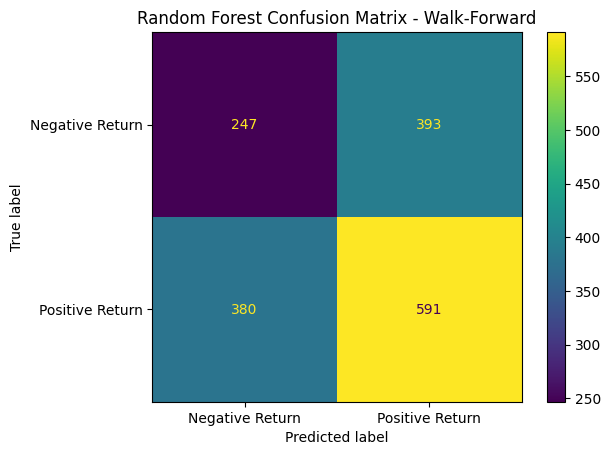

In [ ]:
#random forest and confusion matrix
cm_rf = confusion_matrix(y_true, rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Negative Return", "Positive Return"]
)

disp.plot()
plt.title("Random Forest Confusion Matrix - Walk-Forward")
plt.show()

In [ ]:
#SNN accuracy and F1 score
print("Simple Neural Network - Walk-Forward Validation")
print("Accuracy:", round(accuracy_score(y_true, mlp_pred), 4))
print("F1-score:", round(f1_score(y_true, mlp_pred), 4))

print("\nClassification Report:")
print(classification_report(y_true, mlp_pred))

Simple Neural Network - Walk-Forward Validation
Accuracy: 0.5984
F1-score: 0.7454

Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.03      0.05       640
           1       0.60      0.98      0.75       971

    accuracy                           0.60      1611
   macro avg       0.51      0.50      0.40      1611
weighted avg       0.53      0.60      0.47      1611



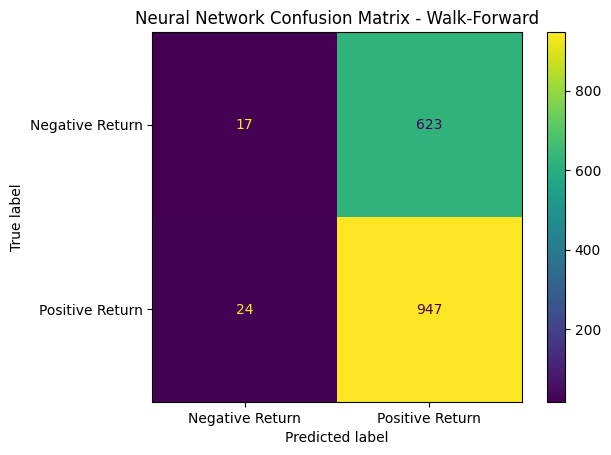

In [ ]:
#SNN confussion matrix
cm_mlp = confusion_matrix(y_true, mlp_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_mlp,
    display_labels=["Negative Return", "Positive Return"]
)

disp.plot()
plt.title("Neural Network Confusion Matrix - Walk-Forward")
plt.show()

In [ ]:
#summary accuracy
model_accuracy_results = pd.DataFrame({
    "Model": ["Random Forest", "Simple Neural Network"],
    "Accuracy": [
        accuracy_score(y_true, rf_pred),
        accuracy_score(y_true, mlp_pred)
    ],
    "F1-score": [
        f1_score(y_true, rf_pred),
        f1_score(y_true, mlp_pred)
    ]
})

model_accuracy_results.round(4)

,Model,Accuracy,F1-score
0,Random Forest,0.5202,0.6046
1,Simple Neural Network,0.5984,0.7454


In [ ]:
#build portfolio return
def build_ml_portfolio_returns(data, signal_col):
    portfolio_returns = []

    for date, group in data.groupby(data.index):
        selected_assets = group[group[signal_col] == 1]

        if len(selected_assets) > 0:
            # Equal weight among selected assets
            portfolio_return = selected_assets["actual_return"].mean()
            selected_tickers = list(selected_assets["ticker"])
        else:
            # If no assets are selected, assume 0% return for that month
            portfolio_return = 0
            selected_tickers = []

        portfolio_returns.append({
            "Date": date,
            "Portfolio Return": portfolio_return,
            "Selected Assets": selected_tickers,
            "Number of Assets": len(selected_tickers)
        })

    portfolio_returns = pd.DataFrame(portfolio_returns)
    portfolio_returns = portfolio_returns.set_index("Date")

    return portfolio_returns

In [ ]:
#Build Random Forest and Neural Network portfolios:
rf_portfolio = build_ml_portfolio_returns(walk_forward_results, "rf_signal")
mlp_portfolio = build_ml_portfolio_returns(walk_forward_results, "mlp_signal")

rf_portfolio.head()

,Portfolio Return,Selected Assets,Number of Assets
Date,,,
2011-08-31,0.010992,"[TLT, QQQ, MSFT, AAPL, IEF]",5
2011-09-30,-0.019649,"[AAPL, TLT, QQQ, SPY, NVDA, VNQ, IEF]",7
2011-10-31,0.048355,"[IEF, TLT, AAPL, NVDA]",4
2011-11-30,-0.010082,"[VNQ, AAPL, TLT, SPY, QQQ, NVDA, EFA]",7
2011-12-31,-0.012118,"[SPY, TLT, IEF, NVDA]",4


In [ ]:
#check selected asset
rf_portfolio.head(10)


,Portfolio Return,Selected Assets,Number of Assets
Date,,,
2011-08-31,0.010992,"[TLT, QQQ, MSFT, AAPL, IEF]",5
2011-09-30,-0.019649,"[AAPL, TLT, QQQ, SPY, NVDA, VNQ, IEF]",7
2011-10-31,0.048355,"[IEF, TLT, AAPL, NVDA]",4
2011-11-30,-0.010082,"[VNQ, AAPL, TLT, SPY, QQQ, NVDA, EFA]",7
2011-12-31,-0.012118,"[SPY, TLT, IEF, NVDA]",4
2012-01-31,0.054211,"[VNQ, SPY, EFA, TLT, IEF, AAPL, QQQ]",7
2012-02-29,0.044813,"[SPY, QQQ, TLT, AAPL, VNQ, IEF, NVDA, EFA, MSFT]",9
2012-03-31,0.035416,"[EFA, AAPL, VNQ, QQQ, MSFT, IEF]",6
2012-04-30,-0.040165,"[NVDA, MSFT, VNQ, AAPL]",4


In [ ]:
mlp_portfolio.head(10)

,Portfolio Return,Selected Assets,Number of Assets
Date,,,
2011-08-31,-0.017970,"[TLT, EFA, QQQ, VNQ, MSFT, AAPL, SPY, IEF]",8
2011-09-30,-0.034435,"[AAPL, TLT, QQQ, EFA, SPY, NVDA, VNQ, IEF, MSFT]",9
2011-10-31,0.071596,"[MSFT, SPY, EFA, IEF, TLT, QQQ, AAPL, NVDA]",8
2011-11-30,-0.009401,"[VNQ, AAPL, TLT, SPY, IEF, QQQ, NVDA, MSFT]",8
2011-12-31,0.008550,"[QQQ, SPY, MSFT, TLT, IEF, NVDA, AAPL, VNQ]",8
2012-01-31,0.064625,"[VNQ, SPY, MSFT, EFA, TLT, IEF, AAPL, QQQ]",8
2012-02-29,0.044813,"[SPY, QQQ, TLT, AAPL, VNQ, IEF, NVDA, EFA, MSFT]",9
2012-03-31,0.024311,"[EFA, SPY, AAPL, NVDA, VNQ, QQQ, MSFT, TLT, IEF]",9
2012-04-30,-0.014041,"[NVDA, MSFT, SPY, TLT, VNQ, AAPL, QQQ, EFA, IEF]",9


In [ ]:
#build benchmark portfolio
test_dates = rf_portfolio.index
test_monthly_returns = monthly_returns.loc[test_dates]

# Buy and Hold SPY
spy_returns = test_monthly_returns["SPY"]

# Equal Weight Portfolio
equal_weight_returns = test_monthly_returns.mean(axis=1)

# 60/40 Portfolio
portfolio_6040_returns = (
    0.60 * test_monthly_returns["SPY"] +
    0.20 * test_monthly_returns["IEF"] +
    0.20 * test_monthly_returns["TLT"]
)

benchmark_returns = pd.DataFrame({
    "Buy and Hold SPY": spy_returns,
    "Equal Weight": equal_weight_returns,
    "60/40 Portfolio": portfolio_6040_returns,
    "ML Random Forest": rf_portfolio["Portfolio Return"],
    "ML Neural Network": mlp_portfolio["Portfolio Return"]
})

benchmark_returns.head()

,Buy and Hold SPY,Equal Weight,60/40 Portfolio,ML Random Forest,ML Neural Network
Date,,,,,
2011-08-31,-0.054976,-0.020151,-0.004348,0.010992,-0.017970
2011-09-30,-0.069421,-0.034435,-0.010766,-0.019649,-0.034435
2011-10-31,0.109147,0.079520,0.055257,0.048355,0.071596
2011-11-30,-0.004064,-0.010774,0.002700,-0.010082,-0.009401
2011-12-31,0.010449,0.005184,0.017134,-0.012118,0.008550


In [ ]:
#performance metrics
def calculate_cagr(returns, periods_per_year=12):
    cumulative_return = (1 + returns).prod()
    years = len(returns) / periods_per_year
    return cumulative_return ** (1 / years) - 1

def calculate_volatility(returns, periods_per_year=12):
    return returns.std() * np.sqrt(periods_per_year)

def calculate_sharpe_ratio(returns, risk_free_rate=0, periods_per_year=12):
    cagr = calculate_cagr(returns, periods_per_year)
    volatility = calculate_volatility(returns, periods_per_year)

    if volatility == 0:
        return np.nan

    return (cagr - risk_free_rate) / volatility

def calculate_max_drawdown(returns):
    cumulative = (1 + returns).cumprod()
    running_max = cumulative.cummax()
    drawdown = cumulative / running_max - 1
    return drawdown.min()

In [ ]:
#create performance
rf_portfolio.head(10)

,Portfolio Return,Selected Assets,Number of Assets
Date,,,
2011-08-31,0.010992,"[TLT, QQQ, MSFT, AAPL, IEF]",5
2011-09-30,-0.019649,"[AAPL, TLT, QQQ, SPY, NVDA, VNQ, IEF]",7
2011-10-31,0.048355,"[IEF, TLT, AAPL, NVDA]",4
2011-11-30,-0.010082,"[VNQ, AAPL, TLT, SPY, QQQ, NVDA, EFA]",7
2011-12-31,-0.012118,"[SPY, TLT, IEF, NVDA]",4
2012-01-31,0.054211,"[VNQ, SPY, EFA, TLT, IEF, AAPL, QQQ]",7
2012-02-29,0.044813,"[SPY, QQQ, TLT, AAPL, VNQ, IEF, NVDA, EFA, MSFT]",9
2012-03-31,0.035416,"[EFA, AAPL, VNQ, QQQ, MSFT, IEF]",6
2012-04-30,-0.040165,"[NVDA, MSFT, VNQ, AAPL]",4


In [ ]:
rf_portfolio.head(10)

,Portfolio Return,Selected Assets,Number of Assets
Date,,,
2011-08-31,0.010992,"[TLT, QQQ, MSFT, AAPL, IEF]",5
2011-09-30,-0.019649,"[AAPL, TLT, QQQ, SPY, NVDA, VNQ, IEF]",7
2011-10-31,0.048355,"[IEF, TLT, AAPL, NVDA]",4
2011-11-30,-0.010082,"[VNQ, AAPL, TLT, SPY, QQQ, NVDA, EFA]",7
2011-12-31,-0.012118,"[SPY, TLT, IEF, NVDA]",4
2012-01-31,0.054211,"[VNQ, SPY, EFA, TLT, IEF, AAPL, QQQ]",7
2012-02-29,0.044813,"[SPY, QQQ, TLT, AAPL, VNQ, IEF, NVDA, EFA, MSFT]",9
2012-03-31,0.035416,"[EFA, AAPL, VNQ, QQQ, MSFT, IEF]",6
2012-04-30,-0.040165,"[NVDA, MSFT, VNQ, AAPL]",4


In [ ]:
#build benchmark portfolios
test_dates = rf_portfolio.index
test_monthly_returns = monthly_returns.loc[test_dates]

# Buy and Hold SPY
spy_returns = test_monthly_returns["SPY"]

# Equal Weight Portfolio
equal_weight_returns = test_monthly_returns.mean(axis=1)

# 60/40 Portfolio
portfolio_6040_returns = (
    0.60 * test_monthly_returns["SPY"] +
    0.20 * test_monthly_returns["IEF"] +
    0.20 * test_monthly_returns["TLT"]
)

benchmark_returns = pd.DataFrame({
    "Buy and Hold SPY": spy_returns,
    "Equal Weight": equal_weight_returns,
    "60/40 Portfolio": portfolio_6040_returns,
    "ML Random Forest": rf_portfolio["Portfolio Return"],
    "ML Neural Network": mlp_portfolio["Portfolio Return"]
})

benchmark_returns.head()

,Buy and Hold SPY,Equal Weight,60/40 Portfolio,ML Random Forest,ML Neural Network
Date,,,,,
2011-08-31,-0.054976,-0.020151,-0.004348,0.010992,-0.017970
2011-09-30,-0.069421,-0.034435,-0.010766,-0.019649,-0.034435
2011-10-31,0.109147,0.079520,0.055257,0.048355,0.071596
2011-11-30,-0.004064,-0.010774,0.002700,-0.010082,-0.009401
2011-12-31,0.010449,0.005184,0.017134,-0.012118,0.008550


In [ ]:
#performance metrics table
performance_results = []

for portfolio in benchmark_returns.columns:
    returns = benchmark_returns[portfolio].dropna()

    performance_results.append({
        "Portfolio": portfolio,
        "CAGR": calculate_cagr(returns),
        "Annual Volatility": calculate_volatility(returns),
        "Sharpe Ratio": calculate_sharpe_ratio(returns),
        "Maximum Drawdown": calculate_max_drawdown(returns)
    })

performance_table = pd.DataFrame(performance_results)

performance_table


,Portfolio,CAGR,Annual Volatility,Sharpe Ratio,Maximum Drawdown
0,Buy and Hold SPY,0.144214,0.143477,1.005132,-0.239272
1,Equal Weight,0.174927,0.140019,1.249305,-0.302293
2,60/40 Portfolio,0.097200,0.094234,1.031471,-0.234032
3,ML Random Forest,0.139682,0.161297,0.865994,-0.368521
4,ML Neural Network,0.167170,0.134696,1.241088,-0.313334


In [ ]:
#format percent
performance_table_percent = performance_table.copy()

percent_cols = ["CAGR", "Annual Volatility", "Maximum Drawdown"]
performance_table_percent[percent_cols] = performance_table_percent[percent_cols] * 100

performance_table_percent.round(2)

,Portfolio,CAGR,Annual Volatility,Sharpe Ratio,Maximum Drawdown
0,Buy and Hold SPY,14.42,14.35,1.01,-23.93
1,Equal Weight,17.49,14.00,1.25,-30.23
2,60/40 Portfolio,9.72,9.42,1.03,-23.40
3,ML Random Forest,13.97,16.13,0.87,-36.85
4,ML Neural Network,16.72,13.47,1.24,-31.33


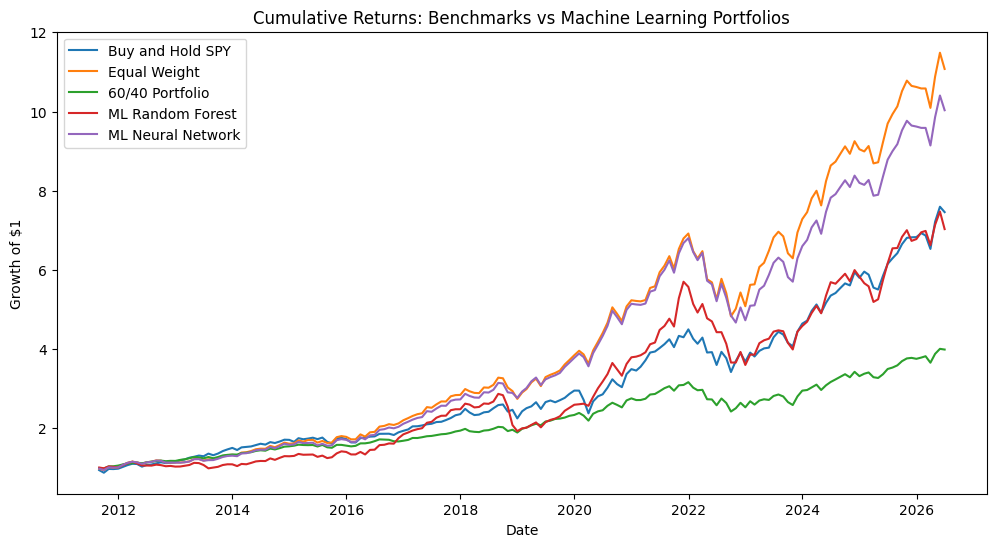

In [ ]:
#plot cumulative return
cumulative_returns = (1 + benchmark_returns).cumprod()

plt.figure(figsize=(12, 6))

for col in cumulative_returns.columns:
    plt.plot(cumulative_returns.index, cumulative_returns[col], label=col)

plt.title("Cumulative Returns: Benchmarks vs Machine Learning Portfolios")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.show()

In [ ]:
#random forest importance features
final_train_data = ml_data[ml_data.index < dates[-1]]

X_final = final_train_data[features]
y_final = final_train_data["target"]

final_rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

final_rf_model.fit(X_final, y_final)

feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": final_rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
1,return_3m,0.232531
2,return_6m,0.201755
0,return_1m,0.191731
4,volatility_6m,0.190616
3,volatility_3m,0.169561
5,trend_signal,0.013806


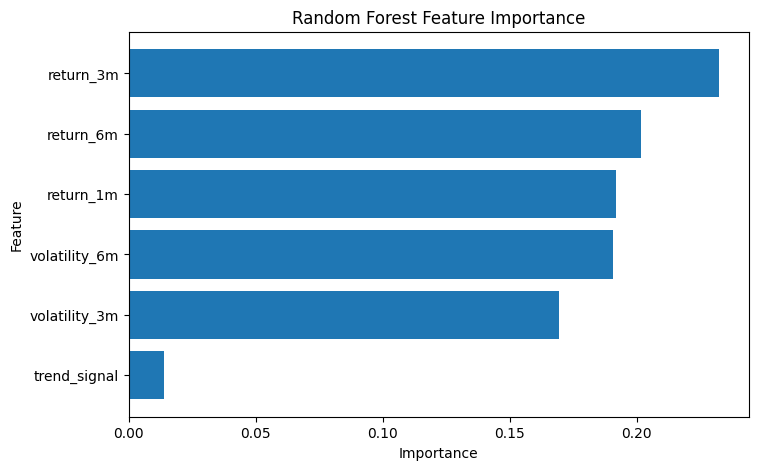

In [ ]:
#plot feature important
plt.figure(figsize=(8, 5))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
#save result
performance_table_percent.round(2).to_csv("portfolio_performance_results.csv", index=False)
feature_importance.to_csv("random_forest_feature_importance.csv", index=False)
benchmark_returns.to_csv("portfolio_monthly_returns.csv")

print("Files saved successfully.")

Files saved successfully.
